In [26]:
pip install deap

Note: you may need to restart the kernel to use updated packages.


In [27]:
import random
import math
import numpy as np
from deap import base
from deap import creator
from deap import tools
from deap import algorithms
import matplotlib.pyplot as plt

In [28]:
# ✅ Un solo objetivo, maximización
creator.create("FitnessMax", base.Fitness, weights=(1.0,))

In [29]:
creator.create("Individual", list, fitness=creator.FitnessMax)

In [30]:
toolbox = base.Toolbox()

In [31]:
toolbox.register("attr_uniform", random.uniform, -100,100)

In [32]:
toolbox.register("Individual", tools.initRepeat, creator.Individual, toolbox.attr_uniform,2)

In [33]:
toolbox.register("Population", tools.initRepeat, list, toolbox.Individual, 10)

In [34]:
def funcion_objetivo(x):
    for i in range(len(x)):
        if x[i] > 100 or x[i] < -100:
            return -1,
    res = math.sqrt(x[0]**2 + x[1]**2)
    return res,

In [35]:
toolbox.register("evaluate", funcion_objetivo)

In [36]:
toolbox.register("mate", tools.cxOnePoint)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=5, indpb=0.1)
toolbox.register("select",tools.selTournament, tournsize=3)

In [37]:
def plot_evolucion(log):
    gen = np.array(log.select("gen"))
    fit_mins = np.array(log.select("min"), dtype=float)
    fit_maxs = np.array(log.select("max"), dtype=float)
    fit_ave = np.array(log.select("avg"), dtype=float)

    fig, ax1 = plt.subplots()
    ax1.plot(gen, fit_mins, "b")
    ax1.plot(gen, fit_maxs, "r")
    ax1.plot(gen, fit_ave, "--k")
    where_mask = fit_maxs >= fit_mins
    ax1.fill_between(gen,fit_mins,fit_maxs,where=where_mask, facecolor="g", alpha = 0.2)
    ax1.set_xlabel("Generation")
    ax1.set_ylabel("Fitness")
    ax1.set_ylim([-10,160])
    ax1.legend(["Min","Max","Avg"], loc="lower center")
    plt.grid(True)
    plt.savefig("Convergencia.eps",dpi = 300)

In [39]:
def main(n_poblacion=10):
    random.seed(42)
    CXPB, MUTPB, NGEN = 0.5, 0.2, 20
    
    # Crear población con el tamaño indicado
    toolbox.register("Population", tools.initRepeat, list, toolbox.Individual, n_poblacion)
    
    pop = toolbox.Population()
    hof = tools.HallOfFame(1)
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("std", np.std)
    stats.register("min", np.min)
    stats.register("max", np.max)
    logbook = tools.Logbook()
    pop, logbook = algorithms.eaSimple(pop, toolbox, cxpb=CXPB, mutpb=MUTPB, ngen=NGEN, stats=stats, halloffame=hof, verbose=True)
    return hof, logbook



In [40]:
if __name__ == "__main__":
    resultados = {}
    for n in [10, 30, 50]:
        print(f"\n===== Población: {n} individuos =====")
        best, log = main(n_poblacion=n)
        resultados[n] = {
            "best_fitness": best[0].fitness.values[0],
            "best_ind": best[0],
            "log": log
        }
        print("Mejor fitness: %f" % best[0].fitness.values[0])
        print("Mejor individuo: %s" % best[0])


===== Población: 10 individuos =====
gen	nevals	avg    	std   	min    	max    
0  	10    	81.3622	28.287	31.2954	116.497
1  	2     	108.322	14.1648	71.337 	126.071
2  	7     	116.868	9.20852	98.8946	136.779
3  	4     	121.084	8.49836	112.226	136.779
4  	7     	125.454	8.40708	116.497	136.779
5  	4     	135.519	3.19937	126.071	136.779
6  	5     	136.779	0      	136.779	136.779
7  	5     	136.779	0      	136.779	136.779
8  	10    	136.779	0      	136.779	136.779
9  	4     	136.358	1.26178	132.573	136.779
10 	6     	136.779	0      	136.779	136.779
11 	6     	136.779	0      	136.779	136.779
12 	7     	136.779	0      	136.779	136.779
13 	7     	136.779	0      	136.779	136.779
14 	8     	122.639	41.2271	-1     	136.779
15 	6     	136.779	0      	136.779	136.779
16 	5     	136.779	0      	136.779	136.779
17 	6     	136.779	0      	136.779	136.779
18 	6     	136.779	0      	136.779	136.779
19 	6     	136.452	0.980645	133.51 	136.779
20 	4     	136.779	0       	136.779	136.779
Mejor fitness: 1

In [41]:
import pandas as pd

tabla = []
for n in [10, 30, 50]:
    log = resultados[n]["log"]
    ultima_gen = log[-1]  # última generación
    tabla.append({
        "Población": n,
        "Mejor Fitness": round(resultados[n]["best_fitness"], 4),
        "Avg final": round(ultima_gen["avg"], 4),
        "Std final": round(ultima_gen["std"], 4),
        "Min final": round(ultima_gen["min"], 4),
        "Max final": round(ultima_gen["max"], 4)
    })

df = pd.DataFrame(tabla)
print(df.to_string(index=False))

 Población  Mejor Fitness  Avg final  Std final  Min final  Max final
        10       136.7789   136.7789     0.0000   136.7789   136.7789
        30       140.1008   140.0666     0.1840   139.0760   140.1008
        50       140.6766   137.8431    19.8347    -1.0000   140.6766


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


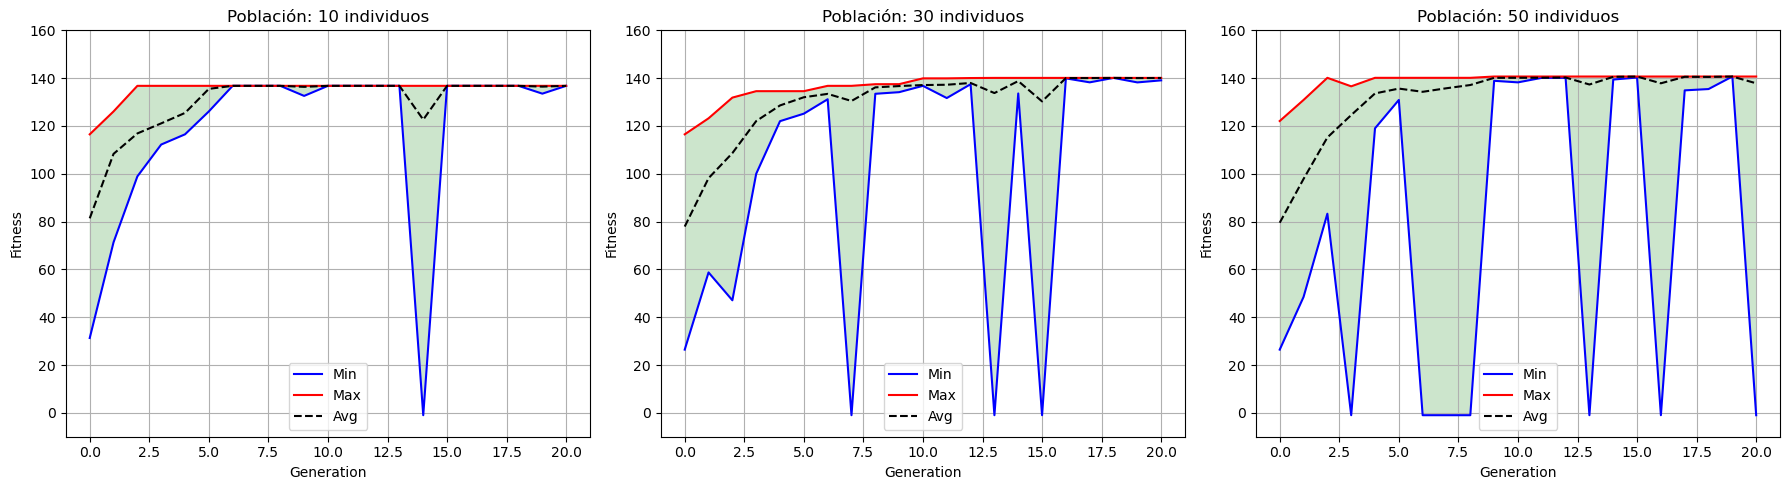

In [42]:
def plot_comparacion(resultados):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for ax, n in zip(axes, [10, 30, 50]):
        log = resultados[n]["log"]
        gen      = np.array(log.select("gen"))
        fit_mins = np.array(log.select("min"), dtype=float)
        fit_maxs = np.array(log.select("max"), dtype=float)
        fit_ave  = np.array(log.select("avg"), dtype=float)
        
        ax.plot(gen, fit_mins, "b", label="Min")
        ax.plot(gen, fit_maxs, "r", label="Max")
        ax.plot(gen, fit_ave,  "--k", label="Avg")
        where_mask = fit_maxs >= fit_mins
        ax.fill_between(gen, fit_mins, fit_maxs, where=where_mask, facecolor="g", alpha=0.2)
        ax.set_title(f"Población: {n} individuos")
        ax.set_xlabel("Generation")
        ax.set_ylabel("Fitness")
        ax.set_ylim([-10, 160])
        ax.legend(loc="lower center")
        ax.grid(True)
    
    plt.tight_layout()
    plt.savefig("Convergencia_comparacion.eps", dpi=300)
    plt.show()

plot_comparacion(resultados)